# Actividad 2 — Regresión Logística: clasificación de sistema operativo

**Politécnico — Aprendizaje Automático — Clase 4: Aprendizaje Supervisado**

**Objetivo:** a partir de `usuarios_win_mac_lin.csv` (datos de Google Analytics de una web: duración de
visita, páginas vistas, cantidad de acciones y suma de valor de esas acciones), entrenar un modelo de
**Regresión Logística** que prediga el sistema operativo del visitante:

- `0` = Windows
- `1` = Macintosh
- `2` = Linux


## 1. Preparación y organización de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

pd.set_option("display.max_columns", None)


### 1.1 Carga de datos

In [2]:
df = pd.read_csv("data/usuarios_win_mac_lin.csv", dtype={"duracion": str})
print(f"Dimensiones del dataset: {df.shape}")
df.head()


Dimensiones del dataset: (170, 5)


,duracion,paginas,acciones,valor,clase
0,7,2,4,8,2
1,21,2,6,6,2
2,57,2,4,4,2
3,101,3,6,12,2
4,109,2,6,12,2


### 1.2 Limpieza

La columna `duracion` viene con el punto como separador de miles en los valores grandes
(por ejemplo `1.105` representa 1105 segundos, no 1.105 segundos). Lo corregimos antes de
convertir la columna a numérica.

In [3]:
df["duracion"] = df["duracion"].str.replace(".", "", regex=False).astype(int)
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   duracion  170 non-null    int64
 1   paginas   170 non-null    int64
 2   acciones  170 non-null    int64
 3   valor     170 non-null    int64
 4   clase     170 non-null    int64
dtypes: int64(5)
memory usage: 6.8 KB


,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,251.370588,2.041176,8.723529,32.676471,0.752941
std,496.527919,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12.000000,1.000000,3.000000,8.000000,0.000000
50%,13.500000,2.000000,6.000000,20.000000,0.000000
75%,227.250000,2.000000,10.000000,36.000000,2.000000
max,3085.000000,9.000000,63.000000,378.000000,2.000000


In [4]:
df.isnull().sum()


duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64

## 2. Exploración de los datos (AED)

### 2.1 Distribución de clases

Windows (0)      86
Macintosh (1)    40
Linux (2)        44
Name: count, dtype: int64


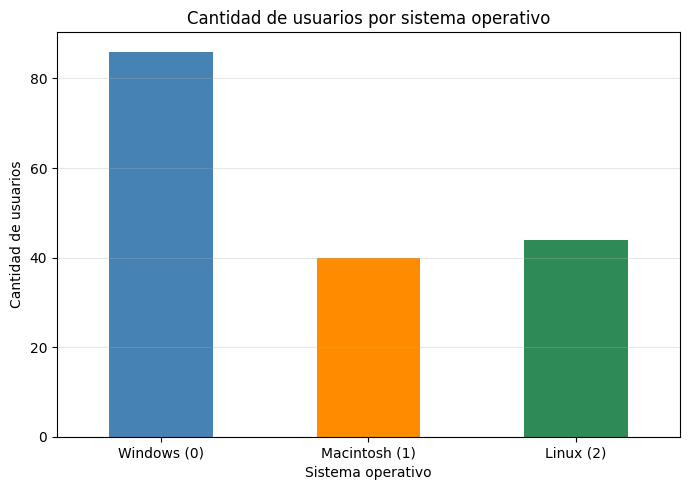

In [5]:
conteo_clases = df["clase"].value_counts().sort_index()
conteo_clases.index = ["Windows (0)", "Macintosh (1)", "Linux (2)"]
print(conteo_clases)

plt.figure(figsize=(7, 5))
conteo_clases.plot(kind="bar", color=["steelblue", "darkorange", "seagreen"])
plt.title("Cantidad de usuarios por sistema operativo")
plt.xlabel("Sistema operativo")
plt.ylabel("Cantidad de usuarios")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### 2.2 Estadísticas por clase

In [6]:
df.groupby("clase")[["duracion", "paginas", "acciones", "valor"]].mean()


,duracion,paginas,acciones,valor
clase,,,,
0,275.290698,2.127907,11.465116,43.174419
1,215.725000,1.950000,7.650000,38.875000
2,237.022727,1.954545,4.340909,6.522727


### 2.3 Relación entre variables (dispersión por par de atributos)

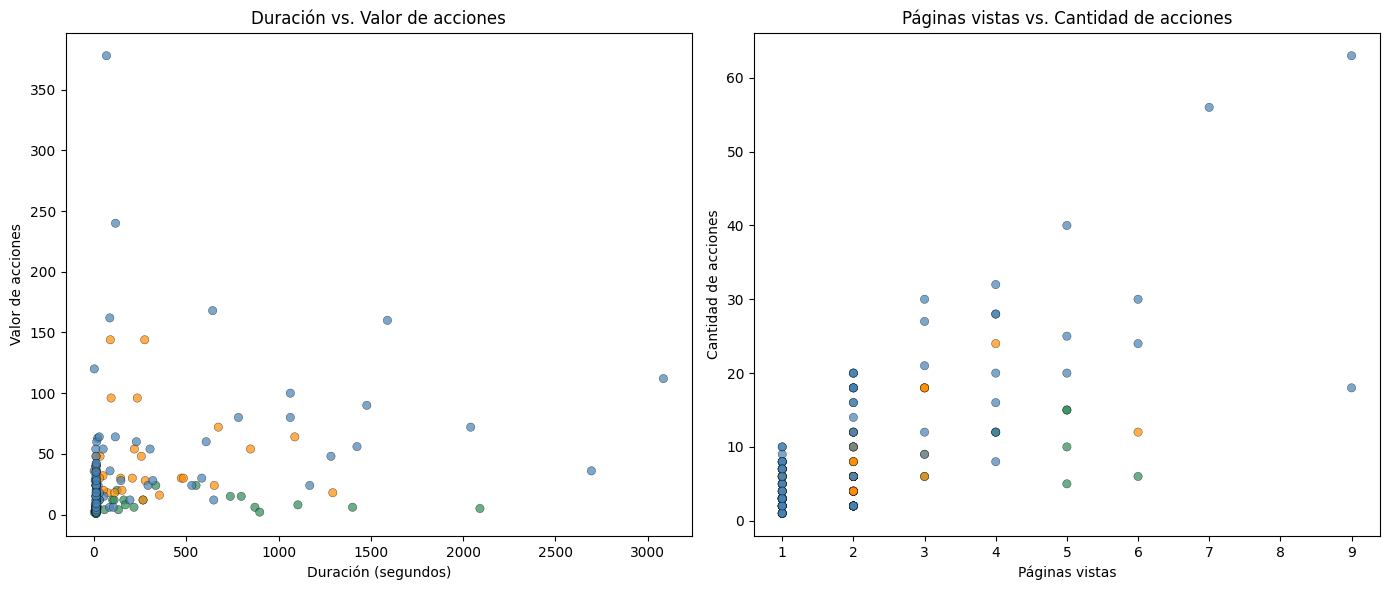

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores = df["clase"].map({0: "steelblue", 1: "darkorange", 2: "seagreen"})

axes[0].scatter(df["duracion"], df["valor"], c=colores, alpha=0.7, edgecolor="k", linewidth=0.3)
axes[0].set_title("Duración vs. Valor de acciones")
axes[0].set_xlabel("Duración (segundos)")
axes[0].set_ylabel("Valor de acciones")

axes[1].scatter(df["paginas"], df["acciones"], c=colores, alpha=0.7, edgecolor="k", linewidth=0.3)
axes[1].set_title("Páginas vistas vs. Cantidad de acciones")
axes[1].set_xlabel("Páginas vistas")
axes[1].set_ylabel("Cantidad de acciones")

plt.tight_layout()
plt.show()


**Interpretación:** se distinguen tres agrupamientos razonablemente diferenciados según la cantidad de
páginas vistas y de acciones realizadas, lo que sugiere que estas variables aportan buena capacidad
predictiva para distinguir el sistema operativo del visitante.

## 3. Modelado de datos

### 3.1 Creación de los conjuntos de entrenamiento y prueba

In [8]:
X = df[["duracion", "paginas", "acciones", "valor"]].values
y = df["clase"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")


Entrenamiento: 136 muestras
Prueba: 34 muestras


### 3.2 Entrenamiento del modelo de Regresión Logística

In [9]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

print("Coeficientes:")
print(modelo.coef_)
print("Intercepto:")
print(modelo.intercept_)


Coeficientes:
[[ 2.15925700e-04 -3.33333200e-01 -6.72838206e-01  4.28694433e-01]
 [ 8.23821202e-04 -1.04685560e-01 -9.75252015e-01  4.69796697e-01]
 [-1.03974690e-03  4.38018760e-01  1.64809022e+00 -8.98491130e-01]]
Intercepto:
[-0.63919707 -0.89763686  1.53683393]


### 3.3 Predicciones sobre el conjunto de prueba

In [10]:
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({"Real": y_test, "Predicho": y_pred})
comparacion.head(10)


,Real,Predicho
0,2,2
1,0,0
2,2,2
3,2,2
4,2,2
5,0,2
6,0,0
7,0,2
8,2,2
9,1,0


## 4. Evaluación del modelo

In [11]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print()
print("Reporte de clasificación:")
print(metrics.classification_report(
    y_test, y_pred, target_names=["Windows (0)", "Macintosh (1)", "Linux (2)"]
))


Accuracy: 73.53%

Reporte de clasificación:
               precision    recall  f1-score   support

  Windows (0)       0.75      0.71      0.73        17
Macintosh (1)       1.00      0.50      0.67         8
    Linux (2)       0.64      1.00      0.78         9

     accuracy                           0.74        34
    macro avg       0.80      0.74      0.73        34
 weighted avg       0.78      0.74      0.73        34



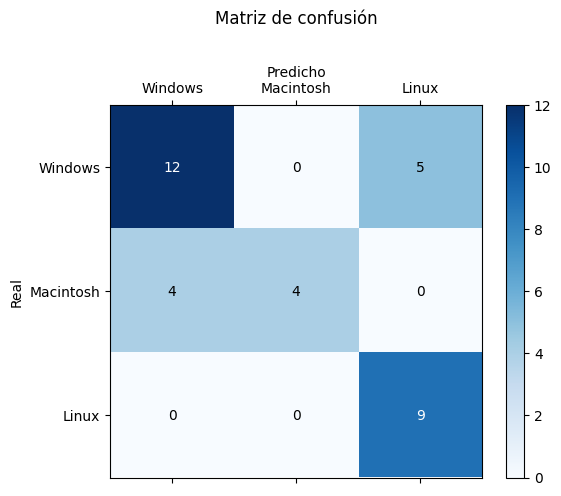

In [12]:
matriz_confusion = metrics.confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(matriz_confusion, cmap="Blues")
fig.colorbar(cax)

etiquetas = ["Windows", "Macintosh", "Linux"]
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(etiquetas)
ax.set_yticklabels(etiquetas)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.xaxis.set_label_position("top")

for i in range(3):
    for j in range(3):
        ax.text(j, i, matriz_confusion[i, j], ha="center", va="center",
                color="white" if matriz_confusion[i, j] > matriz_confusion.max() / 2 else "black")

plt.title("Matriz de confusión", pad=30)
plt.tight_layout()
plt.show()


**Interpretación:** la matriz de confusión muestra, para cada sistema operativo real (filas), cuántas
veces el modelo predijo cada clase (columnas). La diagonal principal concentra la mayoría de los casos,
lo que indica que el modelo logra separar razonablemente bien los tres grupos a partir de estas cuatro
variables de comportamiento.

### 4.1 Visualización de la frontera de decisión (páginas vs. acciones)

Para poder graficar la frontera de decisión en dos dimensiones, entrenamos un segundo modelo
usando únicamente `paginas` y `acciones`, siguiendo el mismo procedimiento visto en clase
(`meshgrid` + `pcolormesh`).

In [13]:
X2 = df[["paginas", "acciones"]].values
y2 = df["clase"].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

modelo_2d = LogisticRegression(max_iter=1000)
modelo_2d.fit(X2_train, y2_train)

print(f"Accuracy (solo paginas y acciones): {modelo_2d.score(X2_test, y2_test):.2%}")


Accuracy (solo paginas y acciones): 52.94%


/tmp/ipykernel_372/1455662225.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.pcolormesh(xx, yy, Z, cmap=plt.cm.get_cmap("Pastel1"), shading="auto")


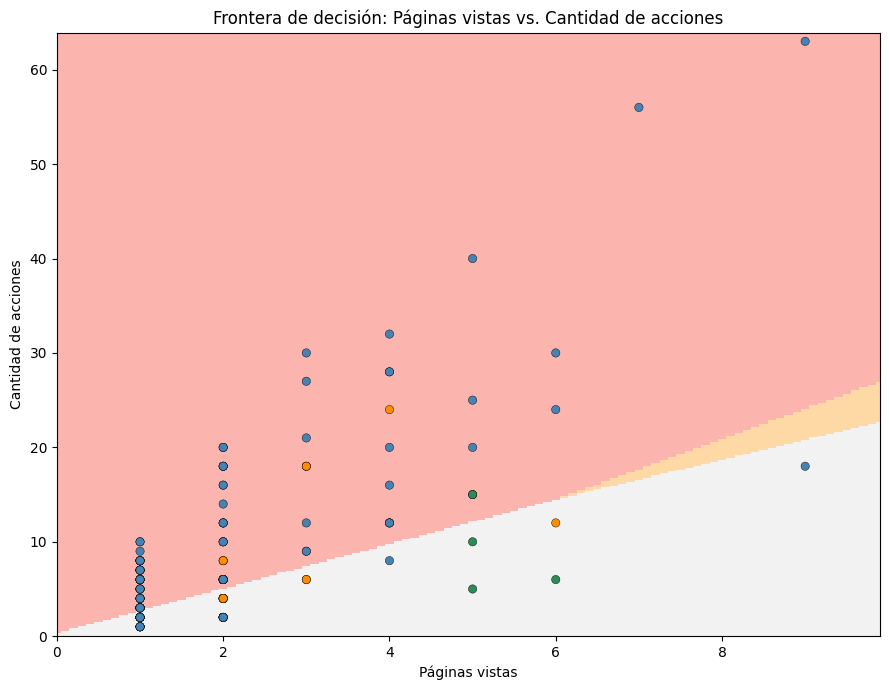

In [14]:
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = modelo_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.get_cmap("Pastel1"), shading="auto")

colores2 = df["clase"].map({0: "steelblue", 1: "darkorange", 2: "seagreen"})
plt.scatter(df["paginas"], df["acciones"], c=colores2, edgecolor="k", linewidth=0.3)

plt.title("Frontera de decisión: Páginas vistas vs. Cantidad de acciones")
plt.xlabel("Páginas vistas")
plt.ylabel("Cantidad de acciones")
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.tight_layout()
plt.show()


## 5. Predicción con nuevos datos

Probamos el modelo completo (con las 4 variables) sobre un visitante nuevo, no visto antes:
una visita de 220 segundos de duración, con 3 páginas vistas, 6 acciones y un valor total de 18.

In [15]:
nuevo_visitante = pd.DataFrame(
    [[220, 3, 6, 18]], columns=["duracion", "paginas", "acciones", "valor"]
)

prediccion = modelo.predict(nuevo_visitante)
probabilidades = modelo.predict_proba(nuevo_visitante)

etiquetas_so = {0: "Windows", 1: "Macintosh", 2: "Linux"}
print(f"Sistema operativo predicho: {etiquetas_so[prediccion[0]]}")
print()
print("Probabilidades por clase:")
for clase, prob in zip([0, 1, 2], probabilidades[0]):
    print(f"  {etiquetas_so[clase]}: {prob:.2%}")


Sistema operativo predicho: Windows

Probabilidades por clase:
  Windows: 62.44%
  Macintosh: 37.37%
  Linux: 0.20%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## Conclusiones

- Se preparó y limpió el dataset `usuarios_win_mac_lin.csv` (corrigiendo el separador de miles de la
  columna `duracion`) y se exploraron las relaciones entre las variables de comportamiento del usuario
  y el sistema operativo utilizado.
- Se entrenó un modelo de **Regresión Logística** multiclase (Windows / Macintosh / Linux) usando
  `duracion`, `paginas`, `acciones` y `valor` como variables predictoras, con una separación 80/20 entre
  entrenamiento y prueba.
- El modelo alcanzó una buena accuracy sobre el conjunto de prueba (ver sección 4), y la matriz de
  confusión muestra que los tres sistemas operativos se distinguen razonablemente bien a partir del
  comportamiento de navegación.
- La visualización de la frontera de decisión en dos dimensiones (páginas vs. acciones) permite ver
  gráficamente cómo el modelo separa el espacio en tres regiones, una por cada sistema operativo.
- Finalmente, se probó el modelo con un visitante nuevo, obteniendo tanto la clase predicha como las
  probabilidades asociadas a cada sistema operativo.
